In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch
from torch.distributions import Normal, Uniform

import sys
sys.path.append('../drnpe')

import lightning

from hydra import compose, initialize
from hydra.utils import instantiate

import matplotlib.pyplot as plt

import math

We load the config and instantiate the data module:

In [2]:
with initialize(version_base=None, config_path="../drnpe/conf"):
    cfg = compose(config_name="config_drnpe")

lightning.seed_everything(cfg.seed)

datamodule = instantiate(cfg.datamodule)

Seed set to 42


We also load in two encoders, one trained with the standard NPE objective and one trained with the DRNPE dual objective:

In [3]:
encoder_npe = instantiate(cfg.encoder)

state_dict = torch.load("../trained_ckpts/network_npe.ckpt")['state_dict']
encoder_npe.load_state_dict(state_dict, strict=False)
encoder_npe.eval()

EncoderDRNPE(
  (net): LocationScaleNet(
    (net): Sequential(
      (0): Linear(in_features=2, out_features=64, bias=True)
      (1): SiLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): SiLU()
      (4): Linear(in_features=64, out_features=64, bias=True)
      (5): SiLU()
      (6): Linear(in_features=64, out_features=2, bias=True)
    )
  )
)

In [4]:
encoder_drnpe = instantiate(cfg.encoder)

state_dict = torch.load("../trained_ckpts/network_drnpe_dual.ckpt")['state_dict']
encoder_drnpe.load_state_dict(state_dict)
encoder_drnpe.eval()

EncoderDRNPE(
  (net): LocationScaleNet(
    (net): Sequential(
      (0): Linear(in_features=2, out_features=64, bias=True)
      (1): SiLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): SiLU()
      (4): Linear(in_features=64, out_features=64, bias=True)
      (5): SiLU()
      (6): Linear(in_features=64, out_features=2, bias=True)
    )
  )
)

We define a function to plot the nominal versus empirical coverage probabilities of credible intervals computed using a trained `encoder`. This function generates a new batch of `num_test_samples` $(z,x)$ pairs. If `likelihood_stdev_multiplier = 1.0`, these pairs are generated from the same generative model used during training. If this multiplier does not equal 1.0, the model used for evaluation is misspecified.

In [5]:
def plot_coverage_probabilities(num_test_samples, encoder, misspec_param):
    num_subplots = len(misspec_param)
    fig, ax = plt.subplots(1, num_subplots, figsize = (4 * num_subplots, 4))
    if num_subplots == 1:
        ax = [ax]
    
    for j in range(num_subplots):
        z = Normal(0.0, datamodule.prior_stdev).sample([num_test_samples])
        x_raw = Normal(z, misspec_param[j] * datamodule.likelihood_stdev).sample([datamodule.num_observations]).permute(1,0)
        
        # Compute sufficient statistics
        sample_mean = x_raw.mean(dim=1, keepdim=True)
        sample_var = x_raw.var(dim=1, unbiased=False, keepdim=True)
        x = torch.cat([sample_mean, sample_var], dim=1)

        mu, logsigma = encoder.net(x)
        sigma = torch.exp(logsigma)

        confidence_levels = torch.linspace(0.05, 0.95, steps = 19)
        quantiles = Normal(0, 1).icdf(1 - (1 - confidence_levels) / 2)

        lower = (mu.unsqueeze(-1) - quantiles * sigma.unsqueeze(-1)).detach().cpu()
        upper = (mu.unsqueeze(-1) + quantiles * sigma.unsqueeze(-1)).detach().cpu()

        coverage_probs = ((z.cpu().unsqueeze(-1) >= lower) * (z.cpu().unsqueeze(-1) <= upper)).float().mean(0)
        
        _ = ax[j].scatter(confidence_levels.cpu(), coverage_probs.cpu())
        _ = ax[j].axline((0,0), slope = 1, color = 'black')
        _ = ax[j].set_xlim(0, 1)
        _ = ax[j].set_ylim(0, 1)
        _ = ax[j].set_title(f'misspecification param = {misspec_param[j]}')
        _ = ax[j].set_xlabel('Nominal coverage')
        _ = ax[j].set_ylabel('Empirical coverage')
    
    _ = fig.tight_layout()

**Scenario 1A:** Train with standard NPE objective, evaluate on correctly specified model:

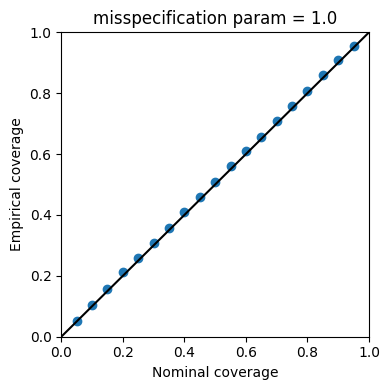

In [6]:
plot_coverage_probabilities(10000, encoder_npe, [1.0])

**Scenario 1B:** Train with standard NPE objective, evaluate on misspecified model with Gaussian likelihood:

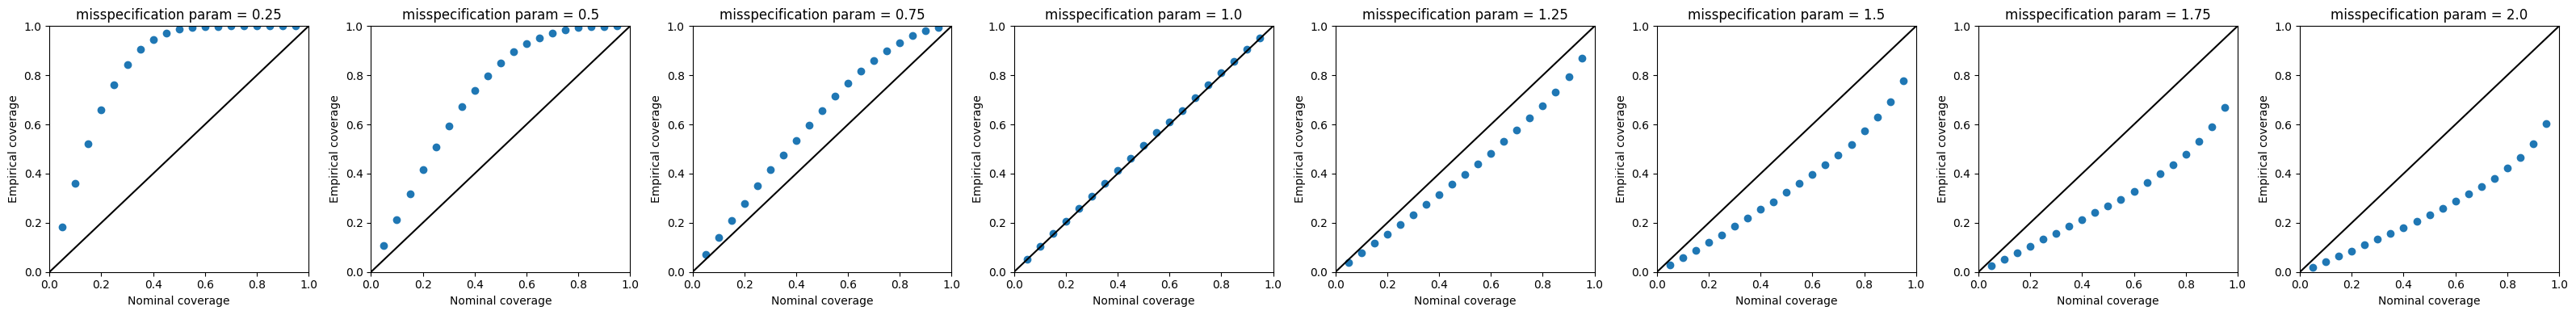

In [7]:
plot_coverage_probabilities(10000, encoder_npe, [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0])

**Scenario 2A:** Train with DRNPE objective, evaluate on correctly specified model:

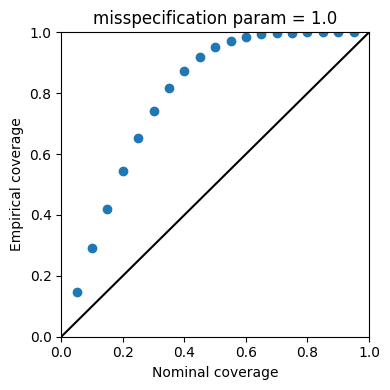

In [8]:
plot_coverage_probabilities(10000, encoder_drnpe, [1.0])

**Scenario 2B:** Train with DRNPE objective, evaluate on misspecified model with Gaussian likelihood:

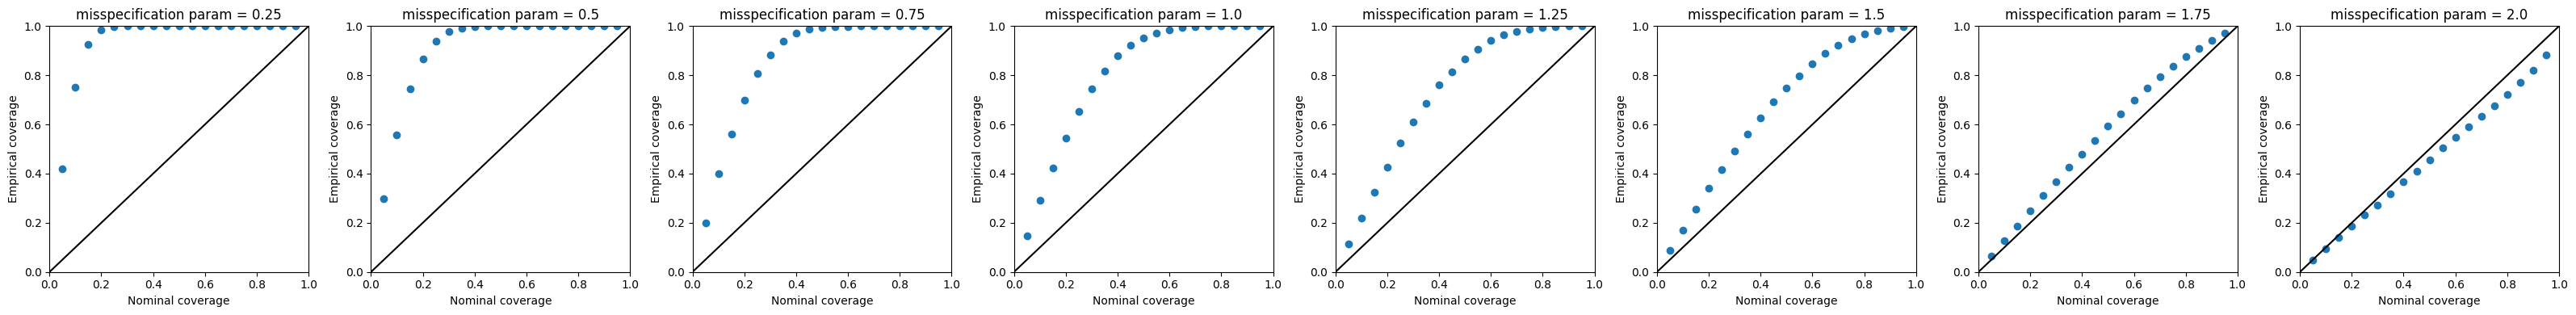

In [9]:
plot_coverage_probabilities(10000, encoder_drnpe, [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0])

---

We examine the misspecified Gaussian model where the variance of the likelihood is twice as large in the true generative model:

In [10]:
num_test_samples = 1000
misspec_param = math.sqrt(2.0)

In [11]:
z = Normal(0.0, datamodule.prior_stdev).sample([num_test_samples])
x_raw = Normal(z, misspec_param * datamodule.likelihood_stdev).sample([datamodule.num_observations]).permute(1,0)

# Compute sufficient statistics
sample_mean = x_raw.mean(dim=1, keepdim=True)
sample_var = x_raw.var(dim=1, unbiased=False, keepdim=True)
x = torch.cat([sample_mean, sample_var], dim=1)

mu_npe, logsigma_npe = encoder_npe.net(x)
sigma_npe = torch.exp(logsigma_npe)

mu_drnpe, logsigma_drnpe = encoder_drnpe.net(x)
sigma_drnpe = torch.exp(logsigma_drnpe)

In [12]:
confidence_levels = torch.linspace(0.01, 0.99, steps = 99)
quantiles = Normal(0, 1).icdf(1 - (1 - confidence_levels) / 2)

In [13]:
lower_npe = (mu_npe.unsqueeze(-1) - quantiles * sigma_npe.unsqueeze(-1)).detach().cpu()
upper_npe = (mu_npe.unsqueeze(-1) + quantiles * sigma_npe.unsqueeze(-1)).detach().cpu()
coverage_probs_npe = ((z.cpu().unsqueeze(-1) >= lower_npe) * (z.cpu().unsqueeze(-1) <= upper_npe)).float().mean(0)

lower_drnpe = (mu_drnpe.unsqueeze(-1) - quantiles * sigma_drnpe.unsqueeze(-1)).detach().cpu()
upper_drnpe = (mu_drnpe.unsqueeze(-1) + quantiles * sigma_drnpe.unsqueeze(-1)).detach().cpu()
coverage_probs_drnpe = ((z.cpu().unsqueeze(-1) >= lower_drnpe) * (z.cpu().unsqueeze(-1) <= upper_drnpe)).float().mean(0)

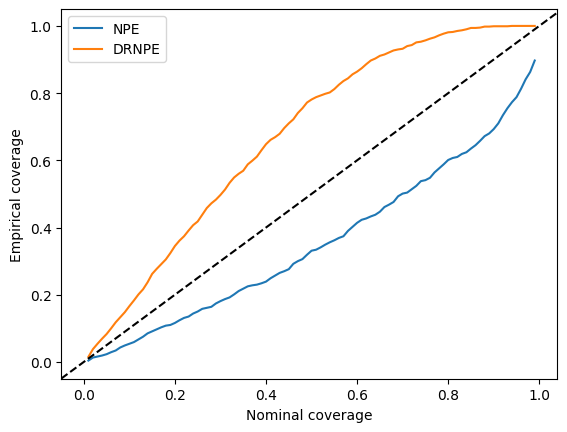

In [14]:
fig, ax = plt.subplots(1, 1)
_ = ax.plot(confidence_levels.cpu(), coverage_probs_npe.cpu(), label = 'NPE')
_ = ax.plot(confidence_levels.cpu(), coverage_probs_drnpe.cpu(), label = 'DRNPE')
_ = ax.axline((0,0), slope = 1, color = 'black', linestyle='dashed')
_ = ax.set_xlabel('Nominal coverage')
_ = ax.set_ylabel('Empirical coverage')
_ = ax.legend()

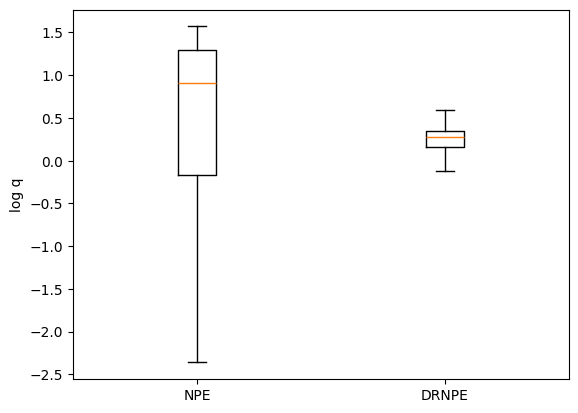

In [15]:
fig, ax = plt.subplots(1, 1)
_ = ax.boxplot([Normal(mu_npe, sigma_npe).log_prob(z).detach().cpu(),
                Normal(mu_drnpe, sigma_drnpe).log_prob(z).detach().cpu()],
                tick_labels=['NPE', 'DRNPE'], showfliers=False)
_ = ax.set_ylabel('log q')

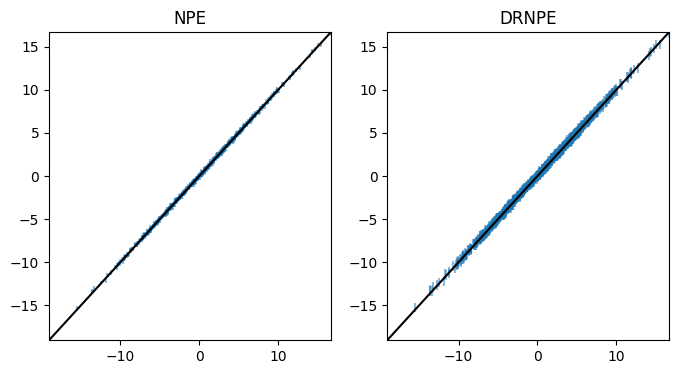

In [16]:
fig, ax = plt.subplots(1, 2, figsize = (8, 4))
_ = ax[0].errorbar(z.detach().cpu(), mu_npe.detach().cpu(), yerr = 1.96 * sigma_npe.detach().cpu(), fmt = 'none', alpha = 0.5)
_ = ax[0].axline((0, 0), slope = 1, color = 'black')
_ = ax[0].set_title('NPE')
_ = ax[1].errorbar(z.detach().cpu(), mu_drnpe.detach().cpu(), yerr = 1.96 * sigma_drnpe.detach().cpu(), fmt = 'none', alpha = 0.5)
_ = ax[1].axline((0, 0), slope = 1, color = 'black')
_ = ax[1].set_title('DRNPE')
for a in ax.flat:
    a.set_xlim(z.min(), z.max())
    a.set_ylim(z.min(), z.max())